In [2]:
# Import pandas for loading and working with tabular data.
import pandas as pd
# Import matplotlib for plotting charts.
import matplotlib.pyplot as plt
# Import seaborn for statistical visualizations.
import seaborn as sns

# Set a clean seaborn visual style.
sns.set_theme(style="whitegrid")

# Load the sales data from the parent Project 1 folder.
bm_sales = pd.read_csv("../bm_sales.csv")
# Load the SKU product data from the parent Project 1 folder.
bm_skus = pd.read_csv("../bm_skus.csv")
# Load the customer data from the parent Project 1 folder.
bm_customers = pd.read_csv("../bm_customers.csv")
# Load revenue grouped by city and store type from the Day 2 folder.
revenue_by_city_storetype = pd.read_csv("../Day 2/q1_revenue_by_city_storetype.csv")
# Load the top five categories by revenue from the Day 2 folder.
top5_categories = pd.read_csv("../Day 2/q2_top5_categories_by_revenue.csv")
# Load the RFM segment summary from the Day 3 folder.
rfm_summary = pd.read_csv("../Day 3/rfm_segment_summary.csv")
# Load cohort retention results from the Day 3 folder.
cohort_retention = pd.read_csv("../Day 3/cohort_retention.csv")

# Print the shape of each loaded DataFrame to confirm the imports.
for dataframe_name, dataframe in {
    "bm_sales": bm_sales,
    "bm_skus": bm_skus,
    "bm_customers": bm_customers,
    "revenue_by_city_storetype": revenue_by_city_storetype,
    "top5_categories": top5_categories,
    "rfm_summary": rfm_summary,
    "cohort_retention": cohort_retention,
}.items():
    print(f"{dataframe_name}: {dataframe.shape}")

bm_sales: (641843, 9)
bm_skus: (200, 7)
bm_customers: (5000, 7)
revenue_by_city_storetype: (9, 5)
top5_categories: (5, 4)
rfm_summary: (5000, 8)
cohort_retention: (406, 4)


In [4]:
# Calculate and print the number of missing values in each bm_sales column.
missing_values = bm_sales.isna().sum()
print("Missing values per column:")
print(missing_values)

# Calculate and print the number of duplicate rows in bm_sales.
duplicate_rows = bm_sales.duplicated().sum()
print("\nNumber of duplicate rows:")
print(duplicate_rows)

# Calculate and print summary statistics for bm_sales.
summary_statistics = bm_sales.describe()
print("\nSummary statistics:")
print(summary_statistics)

Missing values per column:
date                 0
store_id             0
sku_id               0
customer_id     159821
quantity             0
unit_price           0
total_value          0
channel              0
discount_pct         0
dtype: int64

Number of duplicate rows:
45

Summary statistics:
            store_id         sku_id    customer_id       quantity  \
count  641843.000000  641843.000000  482022.000000  641843.000000   
mean       25.491081    1100.547835    2504.986828       2.613120   
std        14.437269      57.684158    1442.340254       1.481563   
min         1.000000    1001.000000       1.000000       1.000000   
25%        13.000000    1051.000000    1260.000000       1.000000   
50%        25.000000    1101.000000    2507.000000       2.000000   
75%        38.000000    1150.000000    3752.000000       4.000000   
max        50.000000    1200.000000    5000.000000       6.000000   

          unit_price    total_value   discount_pct  
count  641843.000000  64184

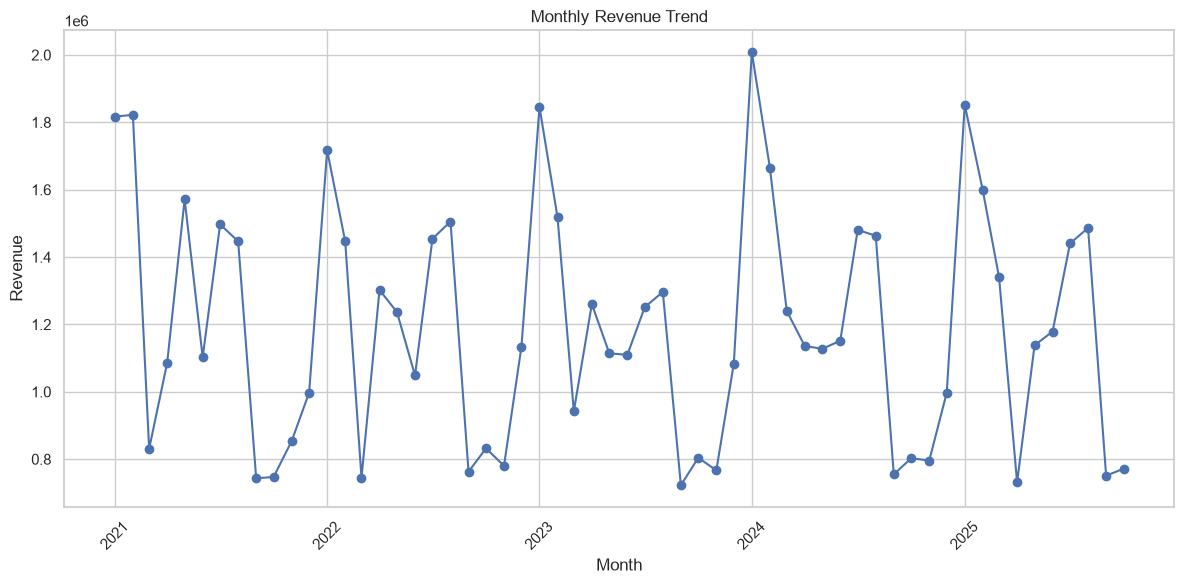

In [6]:
# Convert the sales date column to datetime for chronological grouping.
bm_sales["date"] = pd.to_datetime(bm_sales["date"])

# Create a year-month column for chronological monthly grouping.
bm_sales["sales_month"] = bm_sales["date"].dt.to_period("M").dt.to_timestamp()

# Calculate discounted revenue grouped by year and month.
monthly_revenue = (
    bm_sales.assign(
        revenue=bm_sales["quantity"]
        * bm_sales["unit_price"]
        * (1 - bm_sales["discount_pct"] / 100)
    )
    .groupby("sales_month", as_index=False)["revenue"]
    .sum()
)

# Create a line chart showing monthly discounted revenue.
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue["sales_month"], monthly_revenue["revenue"], marker="o")

# Add a descriptive chart title and axis labels.
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

# Display the chart with a readable layout.
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

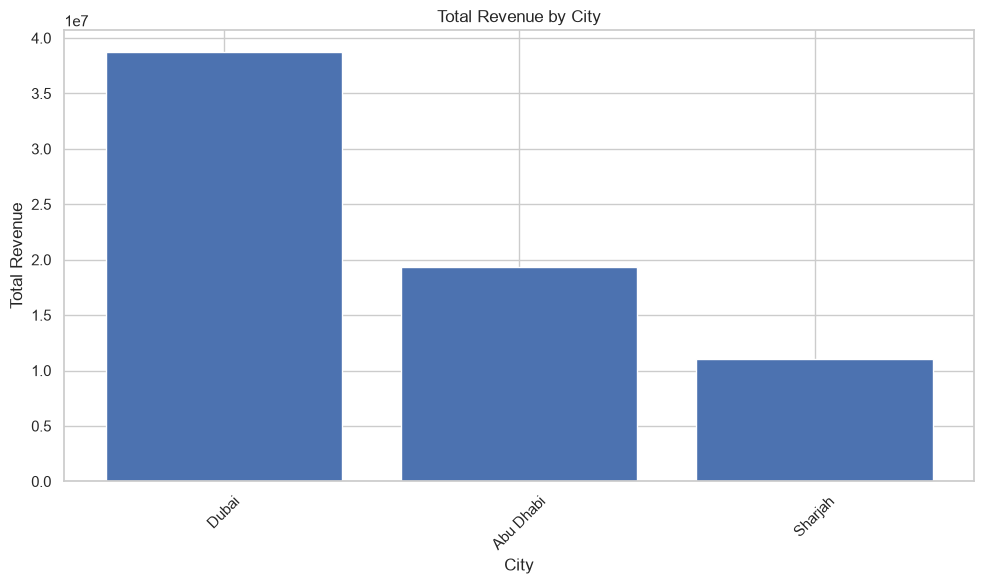

In [ ]:
# Group the nine city-store-type rows by city and sum revenue across store types.
revenue_by_city = (
    revenue_by_city_storetype.groupby("region", as_index=False, sort=False)["revenue"]
    .sum()
    .rename(columns={"region": "city"})
    .sort_values("revenue", ascending=False)
)

# Create a bar chart showing every city in the grouped data.
plt.figure(figsize=(10, 6))
plt.bar(revenue_by_city["city"], revenue_by_city["revenue"])

# Add a descriptive chart title and axis labels.
plt.title("Total Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")

# Display the chart with readable city labels.
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

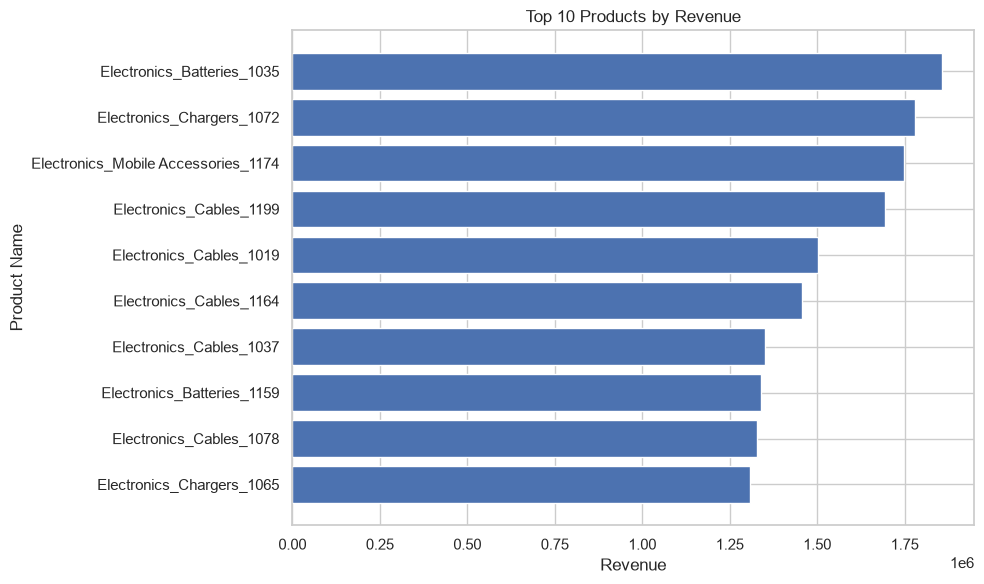

In [8]:
# Merge sales records with SKU details to include product names.
sales_with_skus = bm_sales.merge(bm_skus, on="sku_id", how="inner")

# Calculate discounted revenue for each sales record.
sales_with_skus["revenue"] = (
    sales_with_skus["quantity"]
    * sales_with_skus["unit_price_x"]
    * (1 - sales_with_skus["discount_pct"] / 100)
)

# Aggregate revenue by product and select the top ten products.
top10_products = (
    sales_with_skus.groupby(["sku_id", "sku_name"], as_index=False)["revenue"]
    .sum()
    .nlargest(10, "revenue")
)

# Reverse the top-ten results so the highest-revenue product appears at the top.
top10_products_for_plot = top10_products.sort_values("revenue", ascending=True)

# Create a horizontal bar chart of the top ten products by revenue.
plt.figure(figsize=(10, 6))
plt.barh(top10_products_for_plot["sku_name"], top10_products_for_plot["revenue"])

# Add a descriptive chart title and axis labels.
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Name")

# Display the chart with a readable layout.
plt.tight_layout()
plt.show()

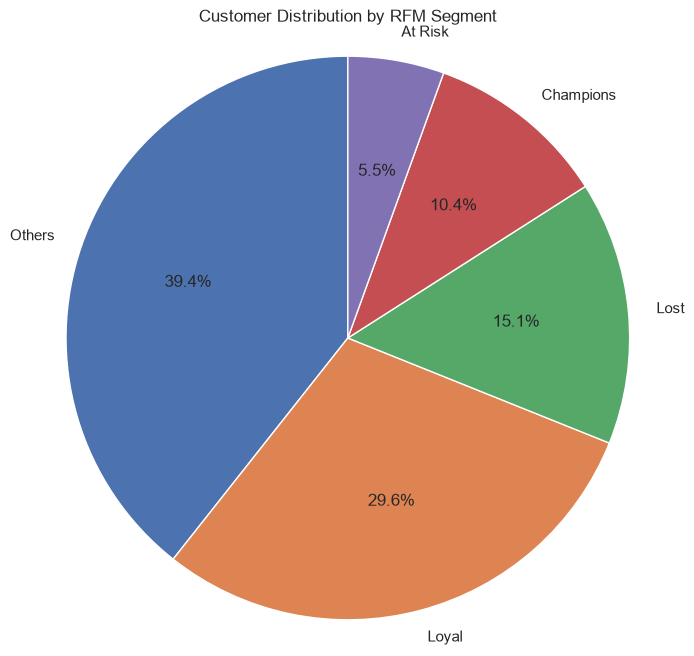

In [9]:
# Count the number of customers in each RFM segment.
segment_counts = rfm_summary["segment"].value_counts()

# Create a pie chart showing the customer distribution by segment.
plt.figure(figsize=(8, 8))
plt.pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct="%1.1f%%",
    startangle=90,
)

# Add a descriptive chart title.
plt.title("Customer Distribution by RFM Segment")

# Display the pie chart as a circle with percentage labels.
plt.axis("equal")
plt.show()

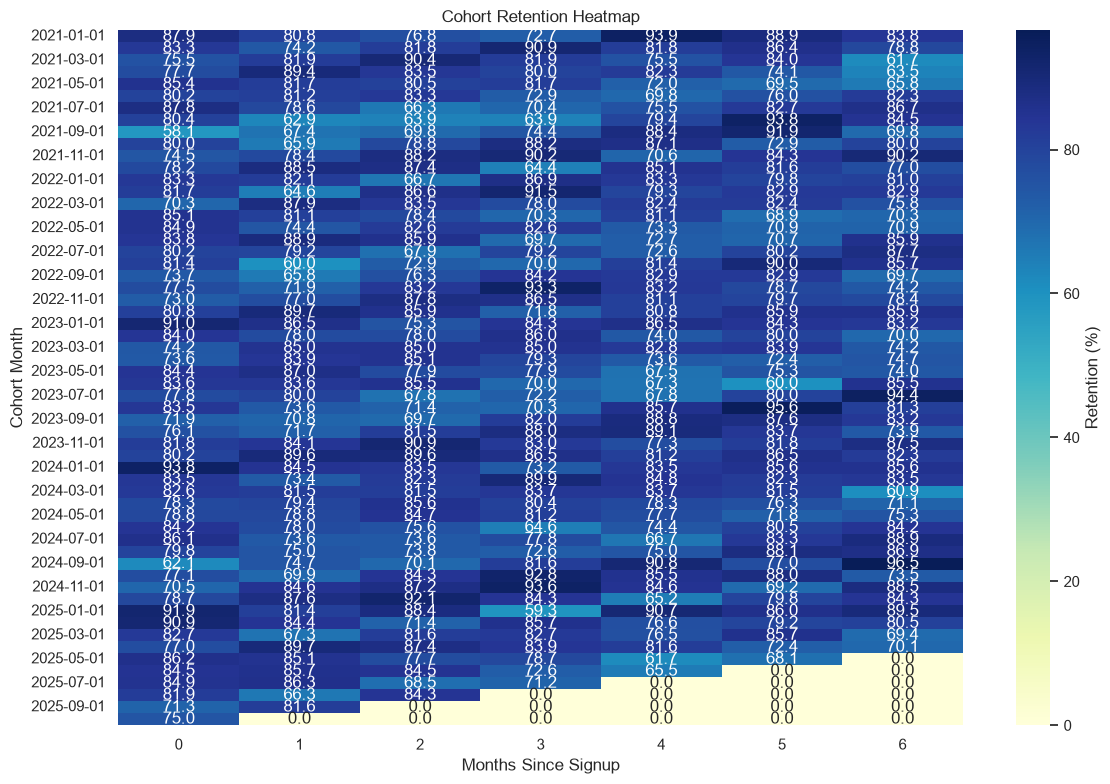

In [10]:
# Pivot cohort retention so cohorts are rows and months since signup are columns.
cohort_retention_pivot = cohort_retention.pivot(
    index="cohort_month",
    columns="months_since_signup",
    values="retention_pct",
)

# Create a heatmap showing retention percentages across cohorts and months.
plt.figure(figsize=(12, 8))
sns.heatmap(
    cohort_retention_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Retention (%)"},
)

# Add a descriptive title and axis labels.
plt.title("Cohort Retention Heatmap")
plt.xlabel("Months Since Signup")
plt.ylabel("Cohort Month")

# Display the heatmap with a readable layout.
plt.tight_layout()
plt.show()

In [11]:
# Calculate discounted revenue for each sales record.
bm_sales["revenue"] = (
    bm_sales["quantity"]
    * bm_sales["unit_price"]
    * (1 - bm_sales["discount_pct"] / 100)
)

# Calculate total discounted revenue across all sales.
total_revenue = bm_sales["revenue"].sum()

# Count the total number of customers.
total_customers = bm_customers["cust_id"].nunique()

# Merge sales with SKU details and calculate revenue by product category.
sales_with_skus = bm_sales.merge(bm_skus[["sku_id", "category"]], on="sku_id", how="inner")
category_revenue = sales_with_skus.groupby("category")["revenue"].sum()
top_category = category_revenue.idxmax()

# Get the city with the highest total revenue from the city revenue DataFrame.
region_revenue = revenue_by_city_storetype.groupby("region")["revenue"].sum()
top_region = region_revenue.idxmax()

# Count customers in the Champions, At Risk, and Lost RFM segments.
segment_counts = rfm_summary["segment"].value_counts()
champions_count = segment_counts.get("Champions", 0)
at_risk_count = segment_counts.get("At Risk", 0)
lost_count = segment_counts.get("Lost", 0)

# Calculate revenue by year and the latest year-over-year growth rate.
bm_sales["date"] = pd.to_datetime(bm_sales["date"])
yearly_revenue = bm_sales.groupby(bm_sales["date"].dt.year)["revenue"].sum().sort_index()
latest_year = yearly_revenue.index[-1]
previous_year = yearly_revenue.index[-2]
yoy_growth_pct = (
    (yearly_revenue.loc[latest_year] - yearly_revenue.loc[previous_year])
    / yearly_revenue.loc[previous_year]
    * 100
)

# Calculate the average discount rate across all sales records.
average_discount_rate = bm_sales["discount_pct"].mean()

# Build a single-row summary DataFrame with all requested metrics.
summary_metrics = pd.DataFrame([{
    "total_revenue": total_revenue,
    "total_customers": total_customers,
    "top_category": top_category,
    "top_region": top_region,
    "champions_count": champions_count,
    "at_risk_count": at_risk_count,
    "lost_count": lost_count,
    "yoy_growth_pct": yoy_growth_pct,
    "average_discount_rate": average_discount_rate,
}])

# Export the single-row summary DataFrame to a CSV file.
summary_metrics.to_csv("summary_metrics.csv", index=False)

# Display the summary metrics to confirm the exported result.
summary_metrics

,total_revenue,total_customers,top_category,top_region,champions_count,at_risk_count,lost_count,yoy_growth_pct,average_discount_rate
0,6.910237e+07,5000,Electronics,Dubai,522,276,756,-15.976393,5.411316
